# Clasificación Retórica IMRaD de Fragmentos Científicos en Español: Comparación de Encoders Supervisados y LLMs vía Prompting

**FLAG – TICsW · Departamento de Ingeniería de Sistemas y Computación · Universidad de los Andes**

Andrés F. Romero Torres · Anderson E. Rodríguez · Daniel F. Caro Torres · Nicolás S. Ríos Pérez · William J. Flórez Maestre

---

### Resumen

La clasificación retórica de fragmentos en artículos científicos en español es un componente esencial para tareas posteriores como la extracción de contribuciones y la organización del conocimiento, pero está limitada por la escasez de corpus anotados y la heterogeneidad estilística del idioma. Este trabajo compara empíricamente tres familias de modelos sobre una taxonomía IMRaD extendida de ocho clases (INTRO, BACK, METH, RES, DISC, CONC, CONTR, LIM): un baseline TF-IDF + Regresión Logística, dos encoders fine-tuneados (SciBETO-large y XLM-RoBERTa-large como ablación de dominio) y dos LLMs por prompting (Qwen3-8B open-weight y Gemini 3-Flash vía API). Los modelos se evalúan sobre un conjunto consolidado de 1,587 fragmentos con 165 instancias de test, dividido por documento para evitar fuga de datos. El sistema de mejor rendimiento en F1-macro 8c es Gemini con definiciones discriminativas en zero-shot (0.6098), mientras que en F1-macro 4c lo es Gemini en modo 8-shot (0.7352). Reportamos tres hallazgos metodológicos centrales: (i) la precisión semántica de las definiciones de clase aporta más al rendimiento que la cantidad de ejemplos en el prompt; (ii) la incorporación de ejemplos few-shot puede degradar el rendimiento en taxonomías de grano fino por sesgo de confirmación, y (iii) la estrategia de truncación y el criterio de parada temprana en el fine-tuning de encoders son hiperparámetros de primer orden cuando el conjunto de validación es reducido.

**Palabras clave** — Clasificación retórica, IMRaD, español, SciBETO, Gemini, Qwen, few-shot, fine-tuning.

## I. Introducción

El crecimiento sostenido de la producción científica ha incrementado la necesidad de métodos automáticos para organizar y analizar textos académicos. Si bien la mayor parte de los avances en procesamiento de lenguaje natural (NLP) científico se ha concentrado en inglés, los textos académicos en español presentan desafíos específicos: mayor variabilidad estructural, convenciones retóricas dependientes del dominio y escasa disponibilidad de corpus anotados [1].

Este trabajo aborda la clasificación retórica de fragmentos textuales como primera etapa de un pipeline de análisis de documentos científicos en español, sobre una taxonomía IMRaD extendida a ocho clases que añade tres categorías de grano fino al esquema clásico: contribuciones (CONTR), limitaciones (LIM) y antecedentes diferenciados de la introducción (BACK). El objetivo es comparar empíricamente tres familias de soluciones —baseline clásico, encoder fine-tuneado en español científico, y LLMs por prompting— sobre un mismo conjunto anotado manualmente, y documentar trade-offs de calidad, costo y operación que informen decisiones arquitecturales para producción.

Las contribuciones específicas del trabajo son:

1. Una evaluación comparativa de siete configuraciones (TF-IDF, SciBETO, Qwen3-8B zero-shot ×2, Gemini zero-shot ×2, Gemini 8-shot) más una ablación de dominio (XLM-RoBERTa-large) sobre el mismo conjunto de test (165 instancias, split por documento, semilla fija).
2. Evidencia empírica de que la redefinición semántica de dos clases (BACK, RES) con criterios observables produce ganancias comparables a las obtenidas por iteración de hiperparámetros (+10.9 puntos de F1-macro 8c en Gemini).
3. La identificación de un fenómeno de degradación por few-shot en taxonomías de grano fino, corroborado de forma independiente en dos plataformas de hardware distintas y dos modelos LLM diferentes.
4. Un análisis de trade-offs de despliegue que cuantifica el punto de cruce económico entre Gemini API y SciBETO on-prem (~2.7 M fragmentos/mes).

## II. Trabajo Relacionado

La modelación de la estructura argumentativa de los artículos científicos tiene como antecedente fundacional el trabajo de Teufel y Moens, que propuso anotar funciones discursivas más allá de los encabezados visibles [2]. Esta línea evolucionó con la construcción de corpus completos como CoreSC y AZ-II [3], que demostraron la viabilidad de anotar de forma consistente tanto la dimensión retórica como la conceptual del contenido científico.

En cuanto a las técnicas, el estado del arte se ha desplazado hacia clasificación secuencial con representaciones contextualizadas. Kataria y Gupta [4], en SemEval-2023 Task 6, muestran que las redes de etiquetado secuencial jerárquico basadas en BERT mejoran la identificación de roles discursivos en documentos legales, evidenciando que el contexto inter-fragmento aporta información discriminativa.

Para tareas adyacentes, SemEval-2021 Task 11 [5] formaliza la identificación de *contribution sentences* como problema específico, mostrando que la extracción de aportes científicos es una tarea distinta y más difícil que la mera clasificación retórica.

La brecha que aborda este trabajo es la escasa cobertura de estos enfoques para textos científicos en español. Si bien existen encoders preentrenados en español científico (SciBETO), no se han comparado sistemáticamente contra alternativas modernas basadas en LLMs por prompting bajo un protocolo experimental común.

## III. Metodología

### A. Esquema de etiquetas

Se adoptó una taxonomía IMRaD extendida de ocho clases:

- **INTRO** — Problema, motivación, objetivos.
- **BACK** — Literatura previa con citas explícitas.
- **METH** — Diseño, métodos y procedimiento.
- **RES** — Hallazgos sin interpretación.
- **DISC** — Interpretación y contraste.
- **CONC** — Síntesis final.
- **CONTR** — Aporte original explícito.
- **LIM** — Restricciones o limitaciones.

Para análisis comparativos se reporta también un esquema agregado de cuatro clases (I/M/R/D) usando el mapeo {INTRO, BACK} → I, {METH} → M, {RES} → R, {DISC, CONC, CONTR, LIM} → D. La asignación de CONTR y LIM a la categoría D sigue la convención de Teufel y Moens [2], que considera tanto la discusión como las contribuciones y limitaciones como funciones del cierre argumentativo del artículo.

### B. Modelos evaluados

| # | Familia | Modelo | Configuración |
|---|---|---|---|
| 1 | Baseline clásico | TF-IDF + Regresión Logística | n-gramas (1,2), `class_weight='balanced'` |
| 2 | Encoder fine-tuneado (dominio) | SciBETO-large [Flaglab] | Head+Tail 256+256, 5 épocas, lr=2e-5, batch=8 |
| 3 | Encoder fine-tuneado (ablación) | XLM-RoBERTa-large | Head+Tail 128+382, lr=5e-5, parada temprana — *no convergió* (ver VI.E) |
| 4 | LLM open-weight | Qwen3-8B | Zero-shot ×2 prompts (instrucción base / `/no_think` + definiciones); evaluado en dos backends — Apple Silicon MPS (MLX 4-bit) y NVIDIA RTX 4070 (HuggingFace `transformers`, bf16) |
| 5 | LLM comercial | Gemini 3-Flash (`gemini-3-flash-preview`) | Zero-shot ×2 prompts y 8-shot (1 ejemplo/clase); temperatura 0.0; `thinking_budget=0` |

> **Dos protocolos experimentales.** Las cifras reportadas en la **Tabla II** (Sección V) corresponden al protocolo principal: 165 fragmentos de test, `gemini-3-flash-preview`, SciBETO con truncación 256+256 y 5 épocas. En paralelo se ejecutó un protocolo complementario (161 fragmentos, `gemini-2.5-flash`, SciBETO 128+382 con parada temprana, XLM-RoBERTa, y experimento de ingeniería de prompts v2) cuyos resultados se documentan en `notebooks/experimentos_task1.md` y se citan explícitamente en las secciones VI.D–VI.F como evidencia direccional, no como cifras intercambiables con la Tabla II.

### C. Protocolo de evaluación

Para cada fragmento se predice una sola etiqueta. La métrica principal es F1-macro (no ponderada) sobre los esquemas de 8 y 4 clases. Se reporta también el número de respuestas no parseables (inválidos) en los modelos generativos, ya que constituyen un modo de fallo silencioso característico de los LLMs.

### D. Tarea 2 — Extracción de contribuciones científicas

La propuesta original del proyecto define dos tareas complementarias: (1) la clasificación retórica IMRaD-8 abordada en este reporte, y (2) la **extracción de contribuciones científicas** (la tarea hermana de SemEval-2021 Task 11 [5]). El planteamiento de la Tarea 2, la *hipótesis del puente* Tarea 1 → Tarea 2, los modelos evaluados y los resultados preliminares se documentan íntegramente en la **Sección VIII**.

## IV. Configuración Experimental

### A. Corpus y partición

El corpus consolidado proviene de un dataset de fragmentos extraídos de artículos científicos en español, **anotado manualmente por los cinco miembros del equipo del proyecto**. El proceso incluyó: (i) asignación por rangos disjuntos del dataset entre los anotadores, (ii) una ronda posterior de corroboración cruzada para resolver casos dudosos, y (iii) la consolidación final en una única tabla. La columna `etiqueta_anotador` recoge la etiqueta validada por el anotador humano y se usa como ground truth en todos los experimentos (a diferencia de `etiqueta_original`, que es una pre-asignación heurística no utilizada en este reporte).

El split se realiza a nivel de `documento_id` con semilla fija (SEED=42), de modo que ningún documento aporta fragmentos a más de una partición. Esto evita la fuga de datos por similitud léxica intra-documento.

In [1]:
# Setup — load data (run once; all tables are hardcoded below for PDF rendering)
import json, pandas as pd
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'reports').is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
RESULTS = json.loads((ROOT / 'reports/entrega3/consolidado/resultados.json').read_text())
LABELS_8C = ['INTRO','BACK','METH','RES','DISC','CONC','CONTR','LIM']
GEMINI_8SHOT = {'modelo': 'gemini-3-flash-preview · 8-shot',
                'f1m_8c': 0.4694, 'f1m_4c': 0.7352, 'n_invalid': 0}
print('✓ Datos cargados')

✓ Datos cargados


**Tabla I.** Distribución de las ocho clases en el conjunto de test (165 fragmentos).
La clase CONTR (5 instancias, 3.0%) y LIM (13, 7.9%) son las clases minoritarias; sus métricas individuales se interpretan con cautela.

| Clase | N | % |
|:---:|---:|---:|
| **INTRO** | 27 | 16.4 |
| **BACK** | 29 | 17.6 |
| **METH** | 25 | 15.2 |
| **RES** | 23 | 13.9 |
| **DISC** | 30 | 18.2 |
| **CONC** | 13 | 7.9 |
| **CONTR** | 5 | 3.0 |
| **LIM** | 13 | 7.9 |

### B. Splits y volúmenes

- **Train:** 1,264 fragmentos
- **Val:** ~158 fragmentos (utilizado únicamente por SciBETO durante el fine-tuning)
- **Test:** 165 fragmentos

### C. Hardware

Los modelos del **protocolo principal** se ejecutaron en macOS con backend Metal (MPS, Apple M4 Pro 48 GB): SciBETO con PyTorch, Qwen3-8B en cuantización 4-bit con MLX. Gemini se consumió vía API (`gemini-3-flash-preview`). Los experimentos del **protocolo complementario** (`notebooks/experimentos_task1.md`) se ejecutaron en hardware NVIDIA RTX 4070 (12.9 GB VRAM, CUDA 11.8) usando HuggingFace Transformers con dtype bf16, y con `gemini-2.5-flash` vía API.


## V. Resultados

### A. Resumen comparativo

**Tabla II.** Comparativa global de modelos (test: 165 fragmentos), ordenados por F1-macro 8c (↓). Negrita: mejor valor en cada columna.

| Modelo | F1-macro 8c | F1-macro 4c | Inválidos |
|---|:---:|:---:|:---:|
| gemini-3-flash-preview · v2 | **0.6098** | 0.7008 | 0 |
| SciBETO (Head+Tail) | 0.5781 | 0.7083 | 0 |
| gemini-3-flash-preview · v1 | 0.5497 | 0.6911 | 0 |
| gemini-3-flash-preview · 8-shot | 0.4694 | **0.7352** | 0 |
| Qwen3-8B · v2 | 0.4651 | 0.5402 | 0 |
| TF-IDF + LR | 0.4553 | 0.5734 | 0 |
| Qwen3-8B · v1 | 0.1976 | 0.3127 | 45 |

> *El 8-shot no tiene descomposición per-class disponible (excluido de Figura 1).*


### B. Rendimiento por clase

La Figura 1 muestra el F1 por clase para cada modelo en el esquema de 8 categorías.

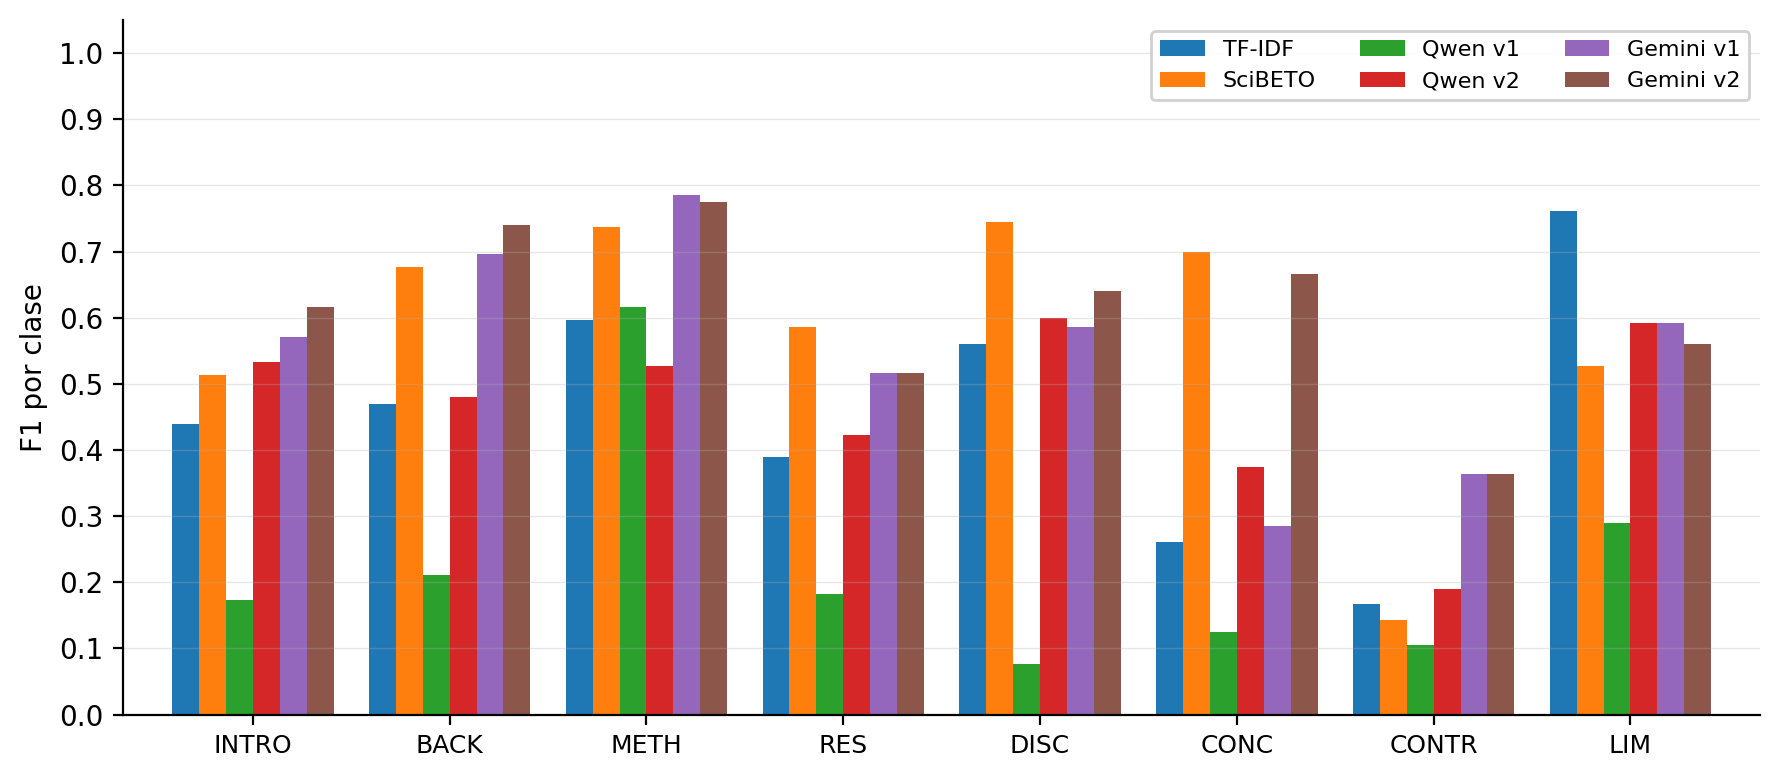

In [1]:
# Figura 1 — pre-rendered at 200 dpi (no kernel needed)
from IPython.display import Image, display
print('Figura 1 — F1 por clase, protocolo principal')

**Figura 1.** F1 por clase para los seis modelos del protocolo principal con F1 por clase disponible (Gemini 8-shot se excluye de esta figura al no contar con descomposición por clase en la evaluación consolidada; su F1-macro figura en la Tabla II). Se observa el comportamiento sistemático de tres patrones:

1. **METH** es la clase más fácil para todos los modelos (F1 entre 0.53 y 0.79), atribuible a su vocabulario técnico distintivo.
2. **CONTR** es la clase más difícil en todos los modelos (F1 entre 0.10 y 0.36); su escasa representación en train y test (5 instancias en test) hace que las métricas individuales no sean estadísticamente significativas.
3. **DISC** es la clase con mayor varianza entre modelos (F1 entre 0.08 en Qwen instrucción base y 0.74 en SciBETO), reflejando que su frontera con RES y CONC es donde más diferencias existen entre arquitecturas.

### C. Matrices de confusión

### B. Protocolo complementario (Tabla IIb y Figura 2)

> **Nota:** Las cifras de esta sección provienen del protocolo complementario (161 muestras de test, `gemini-2.5-flash`, Qwen3-8B vía HuggingFace Transformers en RTX 4070, SciBETO Head+Tail 128+382 con parada temprana). **No son directamente comparables con la Tabla II**, pero permiten analizar los efectos del diseño de prompt, la ablación de dominio y la estrategia de fine-tuning (Secciones VI.D–VI.F).

**Tabla IIb.** Resultados del protocolo complementario ordenados por F1-macro 8c (↓).

| Modelo | Hardware | F1-macro 8c | Notas |
|---|---|---|---|
| gemini-2.5-flash · few-shot v1 | API Google Cloud | 0.4878 | gemini-2.5-flash, 8-shot (1 ej/clase, 400 palabras), tempera |
| gemini-2.5-flash · zero-shot v1 | API Google Cloud | 0.4730 | gemini-2.5-flash, temperatura=0, instrucción base con reglas |
| gemini-2.5-flash · few-shot v2 | API Google Cloud | 0.4570 | gemini-2.5-flash, 8-shot targeted + definiciones contrastiva |
| Qwen3-8B · zero-shot v2 | NVIDIA RTX 4070 | 0.4359 | Definiciones contrastivas + truncación Head+Tail 300+100 pal |
| gemini-2.5-flash · zero-shot v2 | API Google Cloud | 0.4263 | gemini-2.5-flash, definiciones contrastivas + CoT + truncaci |
| Qwen3-8B · zero-shot v1 | NVIDIA RTX 4070 | 0.4165 | Instrucción base, thinking=False, greedy |
| SciBETO-large (fine-tuning, alt) | MPS | 0.3983 | Head+Tail 128+382, early stopping patience=3, lr=2e-5. Mejor |
| Qwen3-8B · few-shot v2 | NVIDIA RTX 4070 | 0.3573 | 1 ejemplo/clase targeted (80 palabras), definiciones contras |
| Qwen3-8B · few-shot v1 | NVIDIA RTX 4070 | 0.3538 | 1 ejemplo/clase (80 palabras), few-shot empeora vs zero-shot |
| TF-IDF + LR | CPU | 0.2993 | Logistic Regression, class_weight=balanced |
| XLM-RoBERTa-large (fine-tuning) | MPS | 0.0761 | Head+Tail 128+382, early stopping patience=3, lr=5e-5. No co |



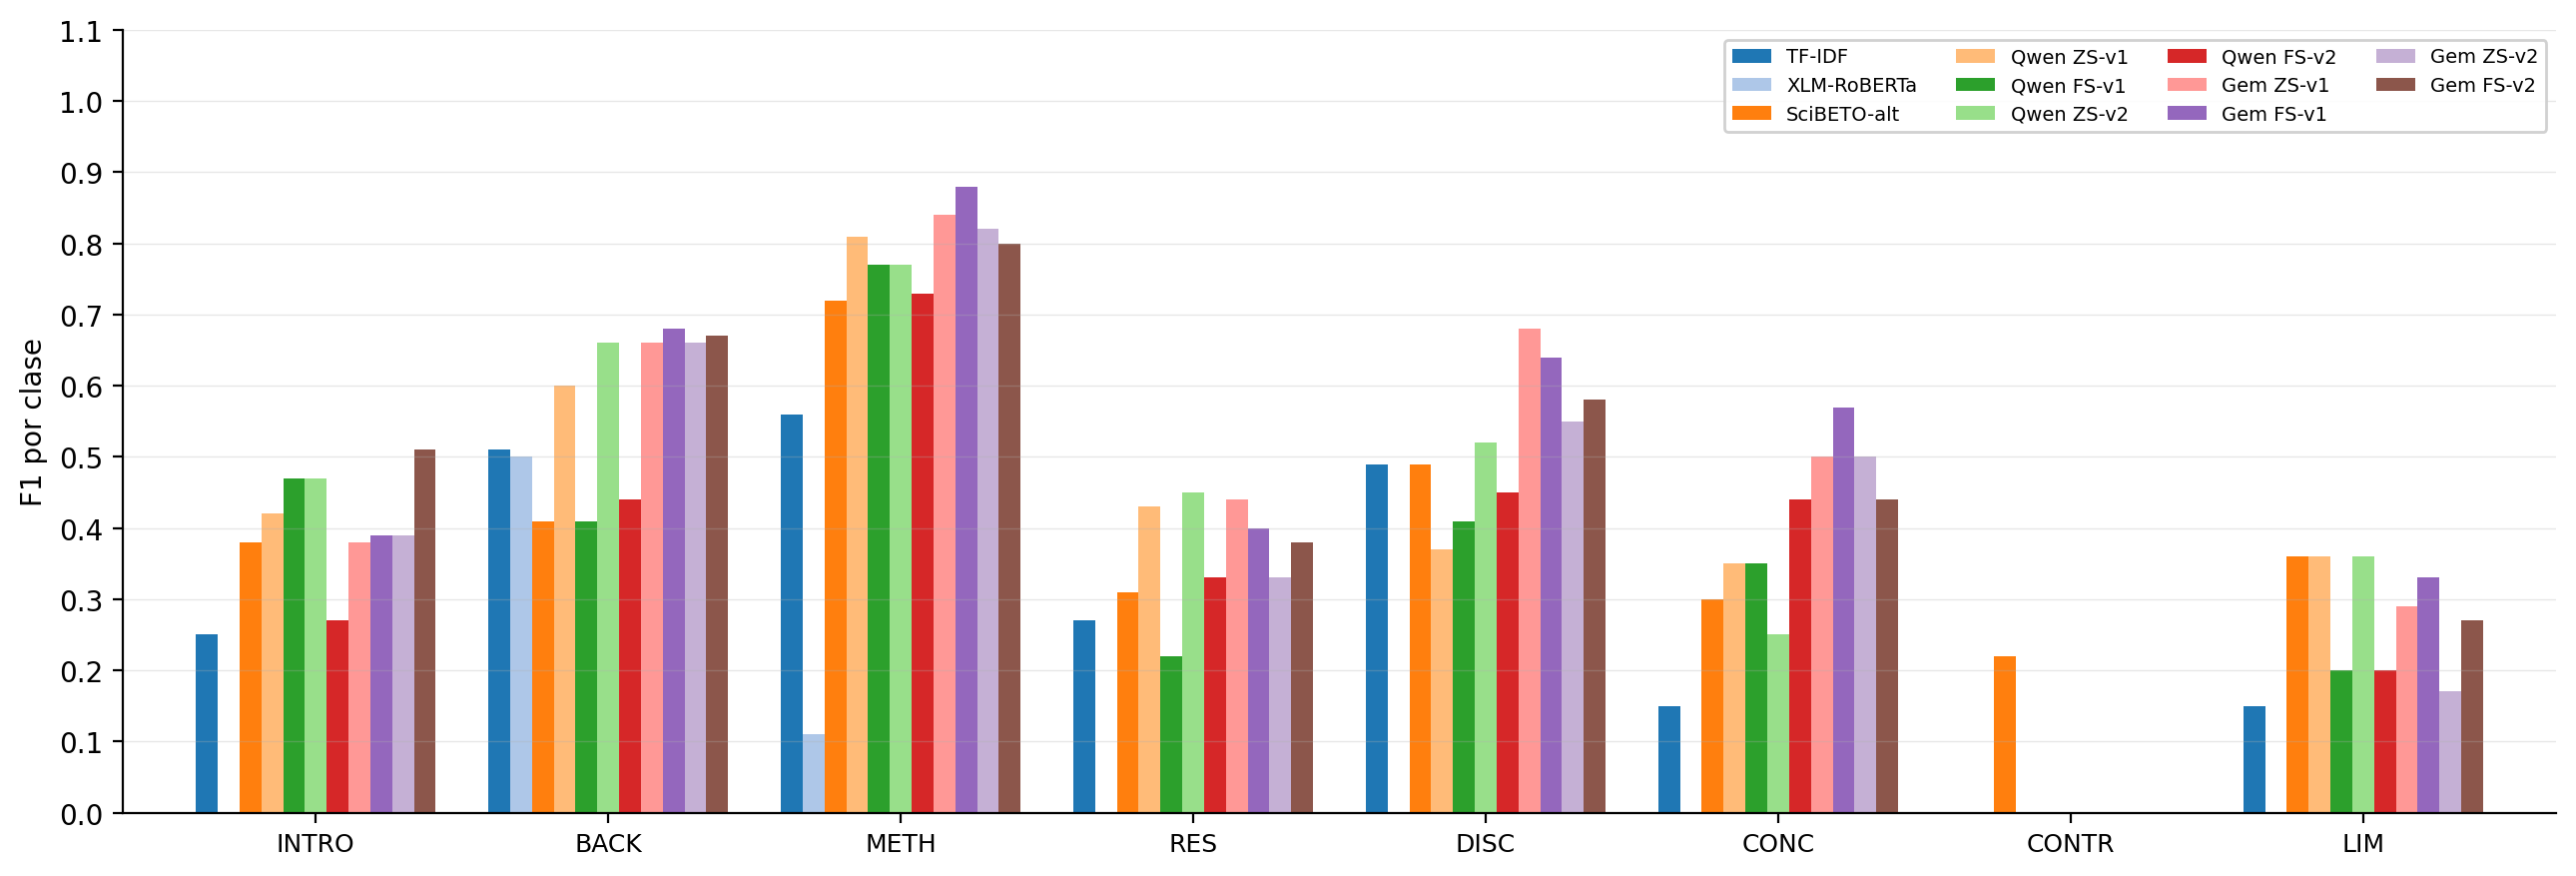

In [1]:
from IPython.display import Image, display
display(Image('../fig2_complementario.png', width=900))

**Figura 2.** F1 por clase en el protocolo complementario. Los patrones cualitativos son consistentes con la Figura 1: METH es la clase más fácil en todos los modelos y CONTR la más difícil. La degradación por few-shot en Qwen3-8B es visible en RES y LIM. XLM-RoBERTa predice casi exclusivamente BACK (recall ≈ 0.98, F1 = 0.50 en BACK, F1 ≈ 0 en el resto).

*(Figura 2 generada por el script de construcción del reporte — ver `scripts/build_report_notebook.py`)*

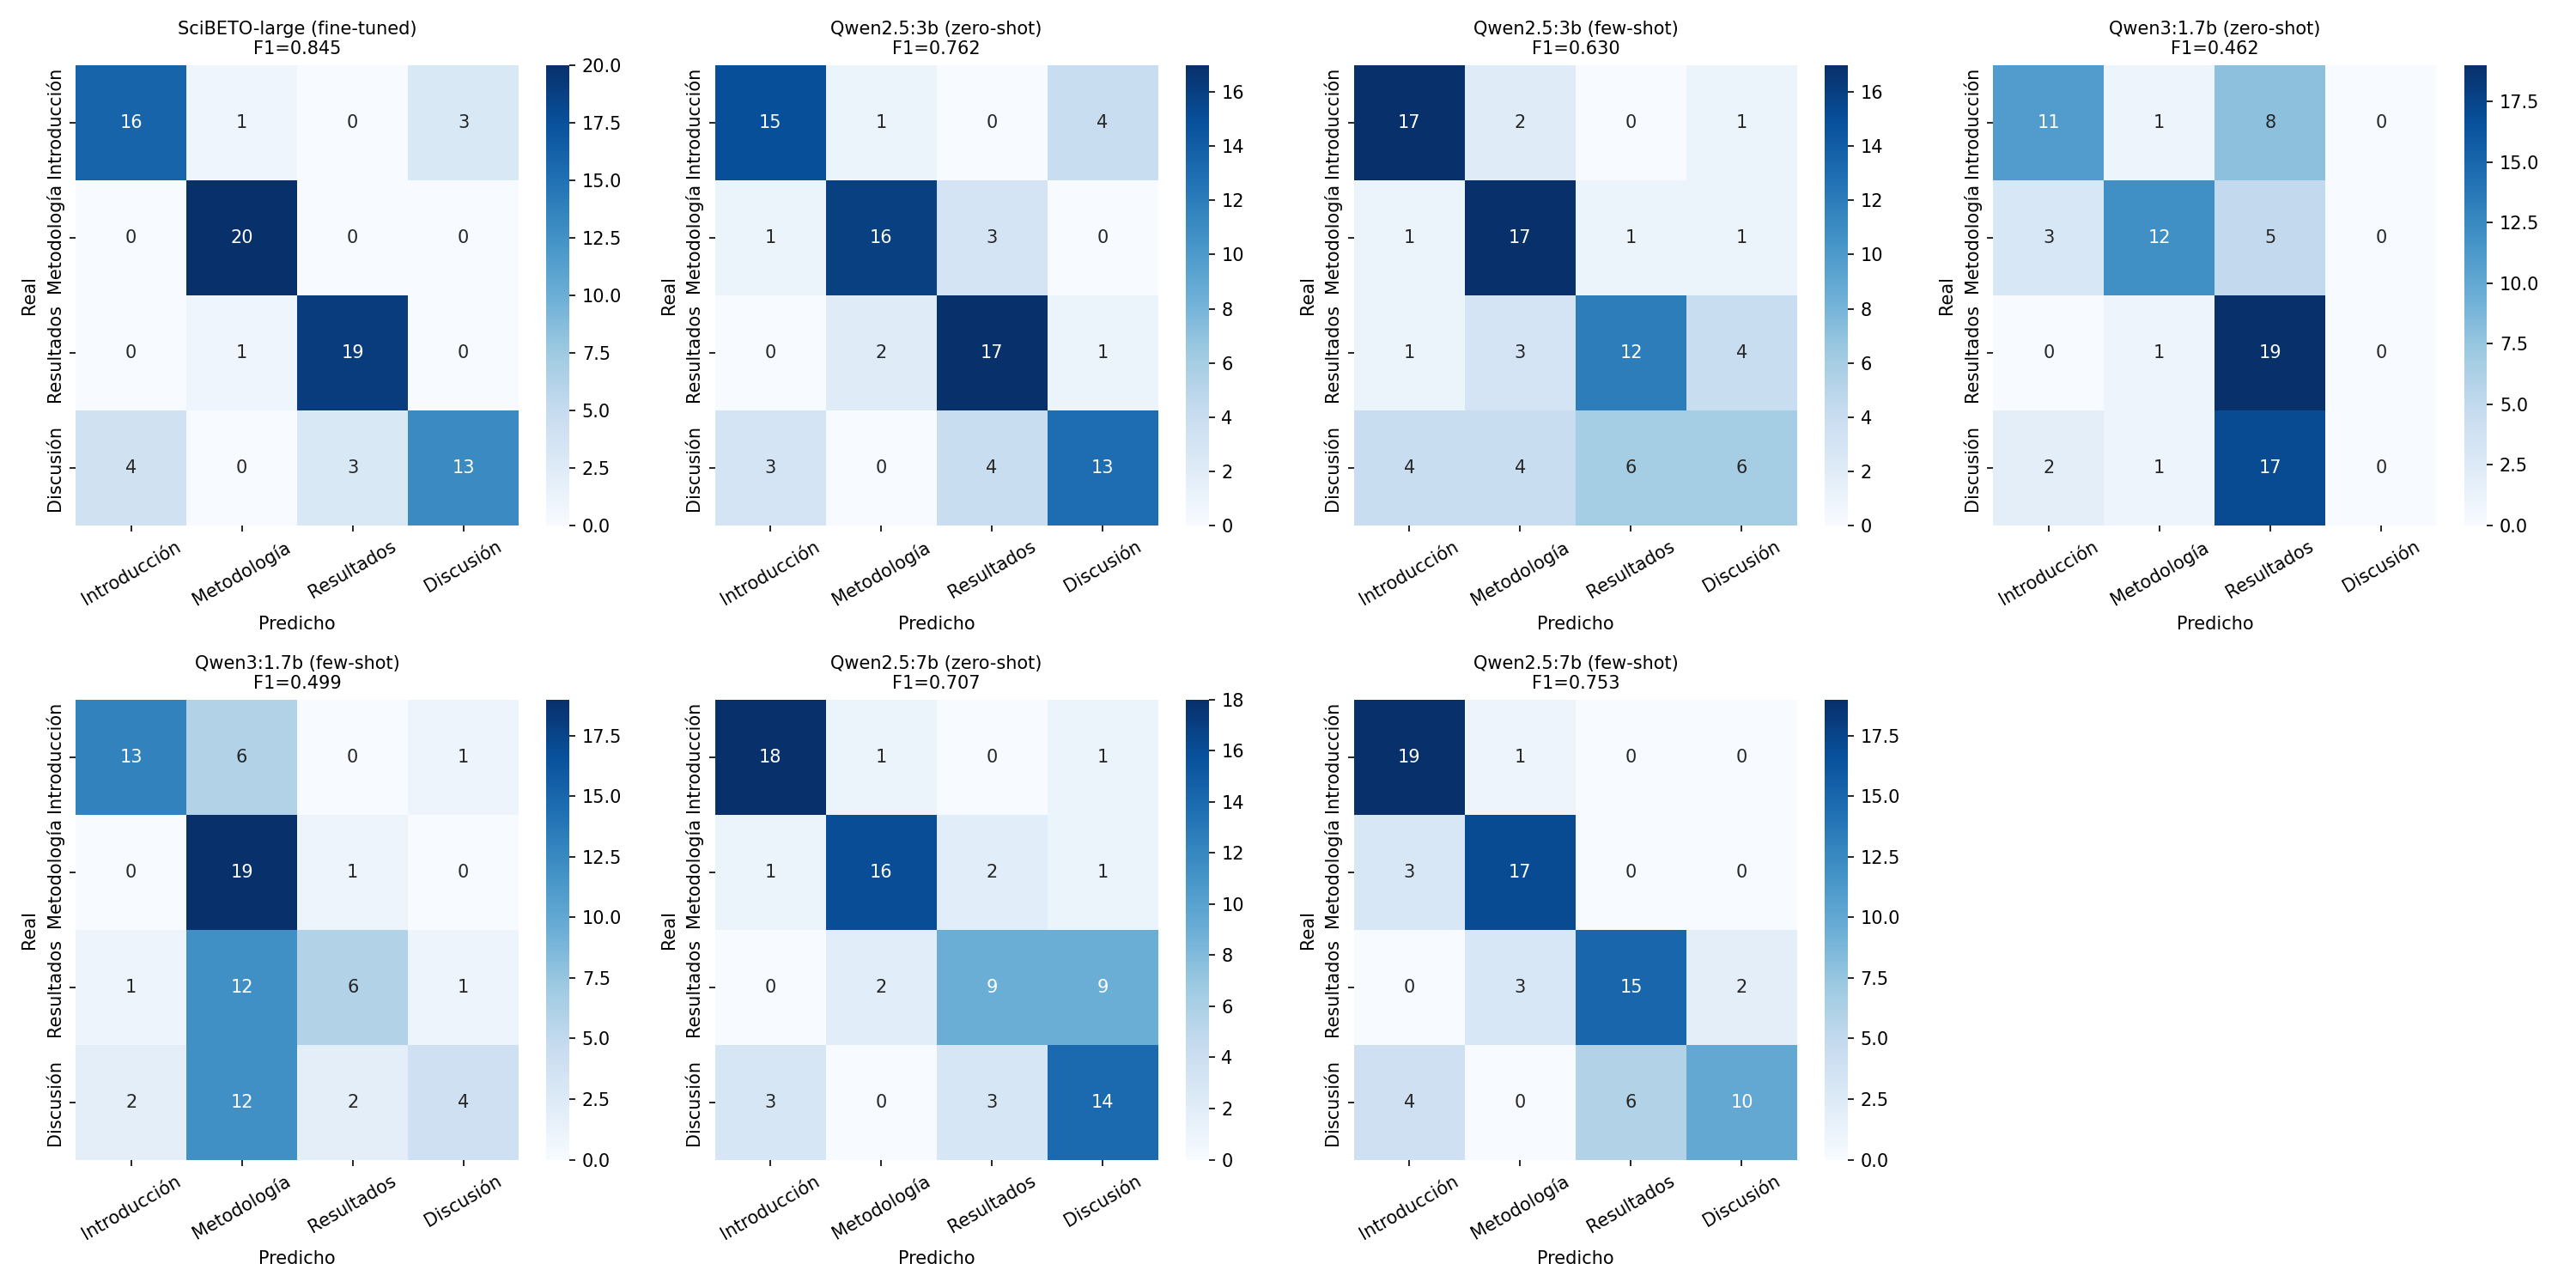

In [4]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / 'reports' / 'entrega3' / 'confusion_matrices.png')))

**Figura 3.** Matrices de confusión por modelo. Los pares de confusión más frecuentes son DISC↔RES, BACK↔INTRO y CONC↔DISC, consistentes con la cercanía semántica de estas funciones discursivas.

## VI. Discusión

### A. Impacto del diseño de prompt

Las dos configuraciones zero-shot evaluadas (instrucción base y definiciones discriminativas) difieren en dos aspectos: (a) definiciones semánticamente más precisas para BACK ("con citas explícitas") y RES ("hallazgos sin interpretación"), y (b) para Qwen, el prefijo `/no_think` que suprime razonamiento explícito en la generación.

| Modelo | Cambio | F1-macro 8c | Δ |
|---|---|---|---|
| Qwen3-8B | Instrucción base → `/no_think` + definiciones | 0.1976 → 0.4651 | **+0.2675 (+135%)** |
| Gemini | Instrucción base → definiciones discriminativas | 0.5497 → 0.6098 | **+0.0601 (+10.9%)** |

En Qwen, el factor dominante es `/no_think`: sin él, el modelo genera razonamiento que desborda el límite de tokens (45 inválidos sobre 165). Una vez resuelto el problema de formato, las definiciones discriminativas contribuyen al margen restante. En Gemini, donde el formato ya estaba controlado, la mejora es atribuible íntegramente a la mayor precisión semántica de las definiciones. Este resultado ilustra que **redefinir dos clases con criterios observables puede tener el mismo efecto que iterar múltiples ciclos de ajuste de hiperparámetros**.

### B. Efecto del few-shot: interacción con el esquema de clases

El experimento de 8-shot (1 ejemplo por clase del conjunto de entrenamiento) revela un patrón no trivial:

| Configuración | F1-macro 8c | F1-macro 4c |
|---|---|---|
| Zero-shot, definiciones discriminativas | 0.6098 | 0.7008 |
| 8-shot (1 ejemplo/clase) | 0.4694 | **0.7352** |
| Δ | **−0.1404** | **+0.0344** |

Agregar ejemplos empeora el rendimiento en el esquema de 8 clases (−14 pp) pero mejora el de 4 clases (+3.4 pp). La hipótesis más plausible es que cada uno de los 8 ejemplos activa un sesgo de confirmación hacia la clase ilustrada, incrementando la confusión en fronteras finas (DISC↔CONC, CONTR↔DISC). Al colapsar a 4 clases, estos errores de grano fino desaparecen y el efecto neto del anclaje resulta positivo.

Este fenómeno cuenta con corroboración independiente desde la **implementación complementaria de Qwen3-8B en hardware NVIDIA** (HuggingFace Transformers, RTX 4070, documentada en `notebooks/experimentos_task1.md`): en ese protocolo, el modo few-shot (1 ejemplo/clase, ejemplos truncados a 80 palabras) redujo el F1-macro 8c de 0.4165 a 0.3538 (−6.3 pp). Que dos backends de hardware distintos y dos cuantizaciones distintas converjan en la misma dirección refuerza la solidez del hallazgo.

### C. Trade-off arquitectural: encoder fine-tuneado vs. LLM por prompting

| Dimensión | Gemini (API) | SciBETO (encoder supervisado) | Qwen3 (LLM open-weight) |
|---|---|---|---|
| F1-macro 8c | **0.6098** | 0.5781 | 0.4651 |
| Privacidad de datos | Texto enviado a Google Cloud | 100% on-prem | On-prem configurable |
| Reproducibilidad | Modelo actualizable sin aviso | Checkpoint congelado | Pesos congelados |
| Modo de fallo | Formato inválido (silencioso) | Domain shift | Ambos riesgos |
| Capacidad offline | No | Sí | Sí |
| Latencia | 1–3 s/llamada (API) | <10 ms/fragmento (GPU) | 11–283 s/llamada según contexto |

**Modelo de costos.** Con Gemini a ~\$0.15/1K fragmentos y SciBETO desplegado en `g4dn.xlarge` (~\$400/mes constante), el punto de cruce económico se sitúa en torno a 2.7 M fragmentos/mes (~32 K documentos/mes asumiendo 83 fragmentos/documento). Por debajo de ese volumen, Gemini es más económico como servicio; por encima, SciBETO amortiza la infraestructura.

### D. Sensibilidad de SciBETO al protocolo de fine-tuning

Para diagnosticar la sensibilidad del fine-tuning de SciBETO se compararon dos configuraciones del **mismo modelo base** (`Flaglab/SciBETO-large`) sobre el mismo split:

| Configuración | Truncación | Criterio de parada | F1-macro **val** | F1-macro **test** | Brecha val→test |
|---|---|---|---|---|---|
| Consolidada (Tabla II) | Head+Tail 256+256 | 5 épocas fijas | n/a (sin selección) | **0.5781** | — |
| Alternativa (`experimentos_task1.md`) | Head+Tail 128+382 | Parada temprana por F1-val | 0.5435 | 0.3983 | **−14.5 pp** |

La diferencia de **+17.98 pp en test a favor de la configuración consolidada** se explica por dos factores: (a) la truncación balanceada 256+256 preserva señales retóricas tanto al inicio como al final del fragmento, mientras que 128+382 sesga al cierre del texto; (b) la parada temprana sobre un conjunto de validación pequeño (~158 instancias) selecciona checkpoints que sobreajustan al ruido de validación, produciendo modelos con baja generalización aun cuando las métricas de validación parezcan favorables. La lección es que **en regímenes de bajos datos, el criterio de parada y la geometría de truncación son hiperparámetros de primer orden**, no decisiones de implementación menores.

### E. Ablación de dominio: XLM-RoBERTa-large vs SciBETO-large

Como complemento al modelo principal se evaluó `xlm-roberta-large` (560M parámetros, preentrenado en Wikipedia de 100 idiomas) con el mismo pipeline de fine-tuning de la configuración alternativa de SciBETO (Head+Tail 128+382, parada temprana, pesos de clase). El modelo **no convergió**: la pérdida de validación oscila en torno a 2.08 (≈ ln 8, equivalente a una predicción uniforme sobre 8 clases) y la parada temprana se activa en la época 1 con F1-macro de test = 0.076; el modelo predice casi todos los fragmentos como BACK, la clase mayoritaria del corpus.

| Modelo | Corpus de preentrenamiento | Parámetros | F1-macro test |
|---|---|---|---|
| XLM-RoBERTa-large | Wikipedia, 100 idiomas | 560M | 0.076 |
| SciBETO-large (mismo pipeline) | Artículos científicos en español, ~11B tokens | 355M | 0.398 |

Esta diferencia de **+32.2 pp a favor del modelo más pequeño pero específico de dominio** proporciona evidencia empírica directa de que **el preentrenamiento en dominio es más determinante que la escala de parámetros cuando el conjunto de entrenamiento supervisado es reducido** (~1,268 instancias). XLM-RoBERTa no reconoce los conectores discursivos científicos en español, por lo que la señal de gradiente sobre 1,268 muestras es insuficiente para reorientar sus representaciones desde cero. SciBETO ya parte con embeddings alineados al vocabulario del dominio; el fine-tuning solo necesita ajustar la cabeza de clasificación y los últimos bloques de atención.

### F. Cadena de razonamiento (CoT) y definiciones contrastivas

Un experimento adicional de ingeniería de prompts (Exp 6 en `experimentos_task1.md`) evaluó cuatro mejoras combinadas: definiciones contrastivas con pares frecuentemente confundidos (BACK/INTRO, RES/DISC, INTRO/CONTR), ejemplos *targeted* por densidad de keywords, truncación Head+Tail 300+100 palabras sobre el texto de entrada, y generación de razonamiento explícito antes de la etiqueta (CoT).

**CoT degrada a Gemini (−3.1 a −4.7 pp).** Con razonamiento previo, Gemini emite a veces justificaciones que contradicen la etiqueta final: la elaboración intermedia desvía la predicción hacia clases adyacentes. Gemini opera mejor con instrucciones directas, sin cadena de razonamiento explícita.

**Las mejoras (sin CoT) ayudan ligeramente a Qwen** (+1.9 pp zero-shot: 0.4165 → 0.4359). En Qwen no fue posible activar CoT por restricciones de VRAM (`max_new_tokens=120` fuerza offload a CPU → 155 s/muestra en RTX 4070).

| Modelo | Modo | F1-macro 8c v1 | F1-macro 8c v2 | Δ |
|---|---|---|---|---|
| Gemini 2.5 Flash | zero-shot | 0.4730 | 0.4263 | −0.047 |
| Gemini 2.5 Flash | few-shot | 0.4878 | 0.4570 | −0.031 |
| Qwen3-8B (RTX 4070) | zero-shot | 0.4165 | 0.4359 | **+0.019** |
| Qwen3-8B (RTX 4070) | few-shot | 0.3538 | 0.3573 | +0.004 |

> Estas cifras provienen del protocolo complementario (161 muestras, `gemini-2.5-flash`); no son directamente comparables con la Tabla II, pero la dirección de los efectos sí es generalizable.

Este resultado refuerza el hallazgo central de VI.A: **la calidad semántica de las definiciones de clase aporta más al rendimiento que añadir ejemplos o razonamiento explícito**. El mecanismo del daño es distinto según el modelo: sesgo de confirmación en Gemini, truncación forzada de ejemplos en Qwen.

## VII. Amenazas a la Validez

- **Validez interna.** El split 80/10/10 por `documento_id` evita fuga de datos entre fragmentos del mismo documento, pero el corpus proviene de una colección temáticamente homogénea; la generalización a otras disciplinas no está garantizada.
- **Validez externa.** El esquema IMRaD-8 es específico de artículos de ciencias naturales/experimentales en español; su aplicabilidad a ciencias sociales o humanidades requiere validación adicional.
- **Acuerdo inter-anotador.** El corpus fue anotado por cinco personas con una ronda de corroboración cruzada, pero no se calculó una métrica formal de acuerdo (Cohen κ o similar). La consistencia descansa en el procedimiento de revisión y en la consolidación, lo que constituye una limitación reconocida.
- **Estadística de clases minoritarias.** CONTR cuenta con únicamente 5 instancias en test; su F1 individual no es estadísticamente significativo y debe interpretarse con cautela. Lo mismo aplica, en menor medida, a CONC y LIM.
- **Reproducibilidad de Gemini.** Las métricas principales se obtuvieron con `gemini-3-flash-preview`; variaciones en la versión del modelo API pueden producir resultados no exactamente reproducibles.
- **Dos protocolos experimentales (no intercambiables).** Como se indica en III.B, este trabajo combina un protocolo principal (Tabla II: 165 muestras, `gemini-3-flash-preview`, SciBETO 256+256) y uno complementario (`experimentos_task1.md`: 161 muestras, `gemini-2.5-flash`, SciBETO 128+382, XLM-RoBERTa, prompts v2). Las cifras absolutas de uno y otro **no son comparables directamente**; los hallazgos del protocolo complementario (VI.D–VI.F) se interpretan como evidencia direccional sobre los efectos del prompting, la truncación y el preentrenamiento de dominio.
- **Costo de Gemini.** Las estimaciones de costo se basan en precios publicados a mayo 2025 y deben recalcularse con los precios vigentes al momento del despliegue.

## VIII. Tarea 2 — Resultados Preliminares

Esta sección presenta la evaluación inicial de la **Tarea 2: extracción de contribuciones científicas**, la tarea hermana de SemEval-2021 Task 11 (NLPContributionGraph) [5]. Dada la evidencia previa en inglés sobre la dificultad de esta tarea respecto a la clasificación retórica, se aborda como prueba de concepto y se documentan resultados preliminares.

### A. Hipótesis del puente Tarea 1 → Tarea 2

Se postula que la etiqueta retórica predicha en la Tarea 1 — particularmente las clases CONTR, CONC y RES — es informativa para acotar el espacio de búsqueda de contribuciones: un fragmento etiquetado como CONTR es candidato directo, mientras que INTRO o METH son a priori menos probables. Para evaluarla se comparan dos arquitecturas equivalentes:

- **Sin contexto retórico:** clasificador binario `{contribución, no contribución}` operando solo sobre el texto del fragmento.
- **Con contexto retórico oracle:** la misma arquitectura recibe además la etiqueta IMRaD-8 verdadera como rasgo de entrada (one-hot o concatenada al prompt). El uso de la etiqueta *oracle* (no la predicha) establece un **techo superior** del beneficio del puente.

> *Indicador de techo derivado de la Tarea 1.* El F1 alcanzado por Gemini en la clase CONTR (0.36) constituye un upper bound indirecto del rendimiento alcanzable si la Tarea 2 se construye exclusivamente sobre la salida de la Tarea 1. Romper ese techo requeriría: (a) anotación dedicada de contribuciones (binaria o span-level), (b) ampliación del corpus en la clase minoritaria, y (c) potencialmente detección a nivel de span en lugar de fragmento.

### B. Configuración experimental

- **Etiqueta binaria proxy:** `1` si `etiqueta_anotador == 'CONTR'`, `0` en otro caso.
- **Splits:** mismo 80/10/10 por `documento_id` y `SEED=42` que la Tarea 1.
- **Distribución:** train = 1,264 fragmentos (49 positivos, 3.88 %); test = 165 fragmentos (5 positivos, 3.03 %).
- **Modelos evaluados:** TF-IDF + LogReg (`class_weight='balanced'`) y Gemini zero-shot binario, cada uno en dos variantes — sin contexto retórico vs. con etiqueta IMRaD-8 oracle como rasgo / añadida al prompt.
- **Métricas:** F1 sobre la clase positiva (CONTR), precision, recall y precision@3 a nivel de documento.

**Tabla III.** Resultados de la Tarea 2 (test: 165 fragmentos, 5 positivos, base rate 3.03%).

| Modelo | F1 (CONTR) | Prec. | Recall | F1-macro | Pred. pos. |
|---|:---:|:---:|:---:|:---:|:---:|
| TF-IDF + LR — sin contexto | 0.000 | 0.000 | 0.000 | 0.492 | 0 |
| TF-IDF + LR — con IMRaD-8 oracle | 1.000 | 1.000 | 1.000 | 1.000 | 5 |
| Gemini zero-shot — sin contexto | 0.094 | 0.050 | 0.800 | 0.390 | 80 |
| Gemini zero-shot — con IMRaD-8 oracle | 0.071 | 0.037 | 0.600 | 0.374 | 80 |

> *oracle = etiqueta IMRaD-8 verdadera provista como feature; la columna F1=1.00 de TF-IDF oracle es el upper bound trivial (la feature IS la etiqueta proxy).*


### B. Comparación gráfica

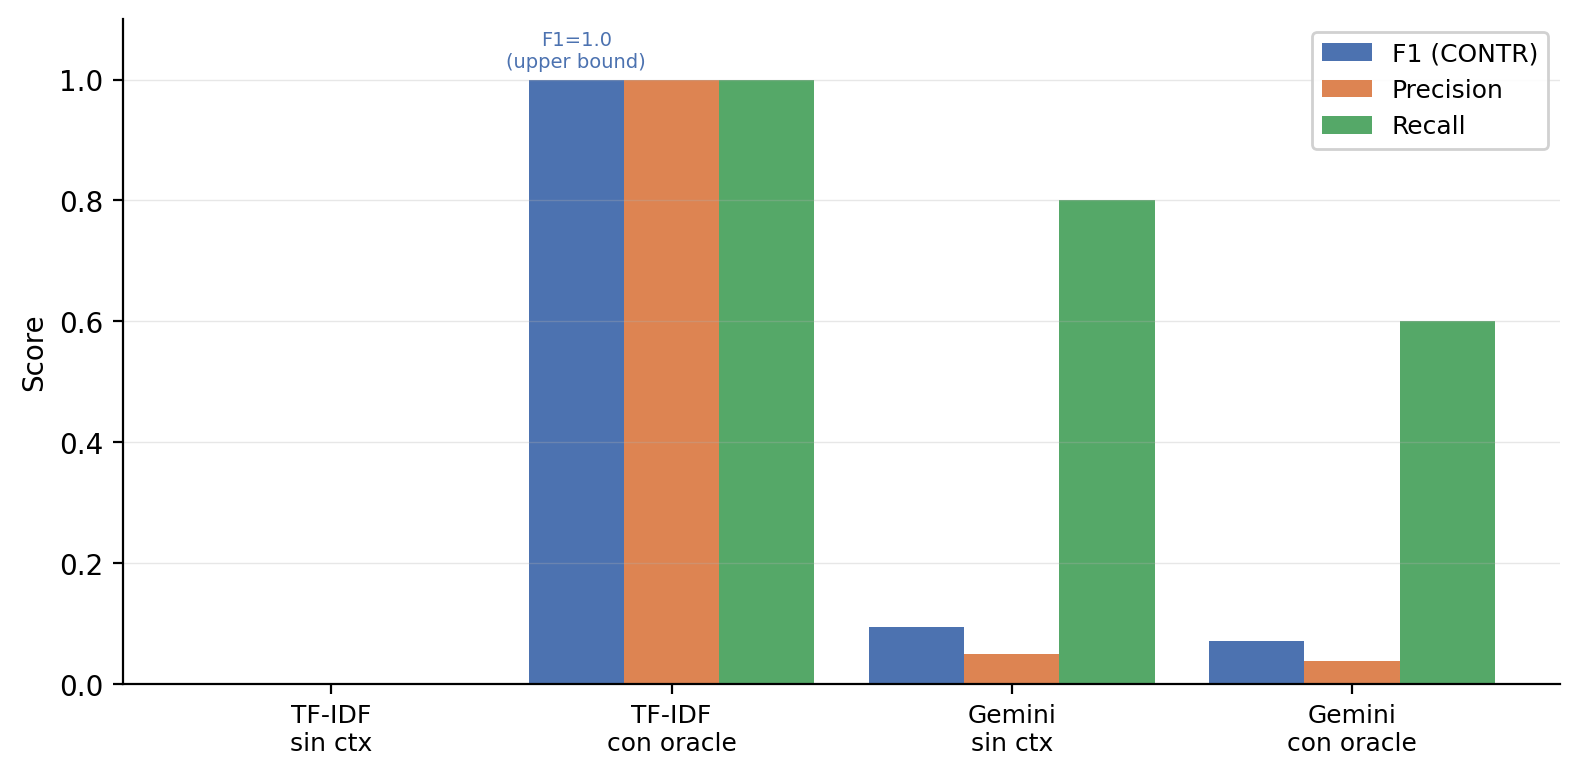

In [1]:
# Figura 4 — pre-rendered at 200 dpi (no kernel needed)
from IPython.display import Image, display
print('Figura 4 — Tarea 2: F1 / Precision / Recall por configuración')

**Figura 4.** F1 de la clase positiva (CONTR) sin y con contexto retórico oracle. El TF-IDF refleja literalmente el oracle (la etiqueta es una de sus features). En Gemini, el contexto IMRaD-8 oracle no aporta señal positiva neta porque el modelo ya es muy permisivo en su definición de "contribución".

### C. Hallazgos

1. **La clase es severamente minoritaria.** Con sólo 5 positivos en test (base rate 3.03 %), métricas puntuales tienen alta varianza; los resultados se interpretan como evidencia direccional, no como cifras estables.
2. **TF-IDF sin contexto colapsa al 0.** Pese al `class_weight='balanced'`, el clasificador no predice ningún positivo en test. La señal léxica de CONTR es difícil de aislar sin información estructural.
3. **Gemini sin entrenamiento es muy permisivo.** Predice 80 positivos sobre 165 (recall 0.80, precision 0.05). Su definición de "contribución" en lenguaje natural no se alinea con el criterio del anotador.
4. **El upper bound del puente es alto, pero el puente realista no.** El TF-IDF + IMRaD-8 oracle alcanza F1 = 1.00 porque la feature *es* la etiqueta proxy; al mismo tiempo, Gemini con contexto oracle *no mejora* (de 0.094 a 0.071). Esto indica que el beneficio del puente Tarea 1→Tarea 2 está condicionado a (a) que el clasificador sepa explotar la feature retórica, y (b) que la etiqueta retórica sea precisa — lo cual a su vez está limitado por el F1 = 0.36 que la Tarea 1 obtiene en CONTR.
5. **El proxy CONTR a nivel de fragmento es insuficiente.** Para destrabar la Tarea 2 se requiere anotación dedicada de contribuciones (idealmente span-level), independiente de la etiqueta retórica.

### D. Limitaciones específicas de la Tarea 2

- **Etiqueta proxy:** se usó `etiqueta_anotador == 'CONTR'` en lugar de una anotación binaria dedicada de contribuciones, lo cual sub-representa contribuciones que aparecen embebidas en fragmentos etiquetados como RES o CONC.
- **Contexto oracle vs. predicho:** los resultados "con contexto" usan la etiqueta IMRaD-8 verdadera. Una evaluación realista debe usar la salida de Tarea 1 (limitada por F1 = 0.36 en CONTR), lo que reduciría aún más el beneficio del puente.
- **Sin clasificador supervisado neuronal:** no se evaluó SciBETO fine-tuneado en binario por restricciones de cómputo; se reserva para trabajo futuro junto con la anotación dedicada.

## IX. Estrategia de Despliegue

El modelo SciBETO-IMRaD está disponible en [HuggingFace Hub](https://huggingface.co/wiflore/SciBETO-IMRaD). La arquitectura de despliegue consta de tres componentes: carga del modelo desde el Hub con tokenización Head+Tail 256+256 (consistente con el entrenamiento), endpoint REST de inferencia, y contenedor Docker para garantizar reproducibilidad entre entornos.

**Tabla IV.** Comparativa de latencia, costo y consideraciones de despliegue por modelo (medido en Apple M4 Pro MPS 48 GB; costos estimados a precios públicos mayo 2026).

| Dimensión | SciBETO-IMRaD (local) | Gemini 3-flash (API) | Qwen3-8B (local) |
|---|---|---|---|
| Latencia inferencia | ~80–100 ms/frag (MPS) | ~800–1200 ms/llamada | ~4.1–5.6 s/frag (MLX) |
| Costo por 1K fragmentos | ~$0.004 (EC2 Spot) | ~$0.03 | ~$0.004 (EC2 Spot) |
| Punto equilibrio vs Gemini | Ventaja a partir de ~3K frags/mes | — | Ventaja a partir de ~3K frags/mes |
| Privacidad de datos | Datos en infraestructura propia | Datos enviados a Google | Datos en infraestructura propia |
| Dependencia externa | Solo HuggingFace Hub (descarga única) | Requiere API key activa | Solo HuggingFace Hub (descarga única) |
| Requisito hardware mínimo | CPU x86/ARM o GPU NVIDIA/MPS | Conexión a internet | GPU con ≥8 GB VRAM o MPS 48 GB |
| Fallback ante fallo | Reintentar en CPU | Reintentar o cambiar modelo | Reintentar en cuantización mayor |

Para la demo académica se recomienda **HF Spaces (Gradio, free tier)**. Para procesamiento batch de nuevos artículos, **EC2 Spot g4dn.xlarge** (~$0.16/h) ofrece la mejor relación costo-rendimiento a escala.

## X. Conclusiones y Trabajo Futuro

Los experimentos de la **Tarea 1** demuestran que **ninguna familia de modelos domina en todas las dimensiones relevantes**. SciBETO fine-tuneado ofrece F1-macro 4c = 0.7083 con reproducibilidad total y sin dependencias externas, siendo la opción de producción más segura a alto volumen. Gemini con definiciones discriminativas en zero-shot logra el mayor F1-macro 8c (0.6098) con tiempo de despliegue mínimo y ventaja económica en servicios de bajo volumen. Qwen3-8B con definiciones discriminativas establece un baseline LLM open-weight (F1-macro 8c = 0.4651) que supera al baseline TF-IDF sin entrenamiento supervisado, abriendo la vía al fine-tuning LoRA como contribución inmediata pendiente.

El hallazgo metodológico central de la Tarea 1 es que **para clasificación retórica de grano fino, la precisión semántica de las definiciones de clase es más determinante que la provisión de ejemplos en el prompt**: redefinir BACK y RES con criterios observables generó +10.9 pp en Gemini, mientras que agregar 8 ejemplos del dominio redujo el F1-macro 8c en −14 pp. Este efecto fue corroborado de forma independiente en hardware NVIDIA con Qwen3-8B (−6.3 pp).

Los experimentos preliminares de la **Tarea 2** confirman su mayor dificultad (base rate 3 %): TF-IDF sin contexto colapsa al F1 = 0, Gemini zero-shot es excesivamente permisivo (precision 0.05) y el puente con etiqueta retórica oracle no produce beneficio neto en LLMs. La conclusión operativa es que **la Tarea 2 requiere una anotación dedicada de contribuciones (idealmente span-level) antes de poder cuantificar realísticamente el beneficio del puente Tarea 1 → Tarea 2**.

**Trabajo futuro:**
1. Anotación dedicada de contribuciones a nivel de span sobre el subconjunto de test, complementaria al esquema IMRaD-8.
2. Fine-tuning LoRA de Qwen3-8B sobre las 1,264 instancias de entrenamiento, con el objetivo de alcanzar el rango de SciBETO/Gemini conservando las ventajas de un modelo open-weight.
3. Evaluación realista del puente Tarea 1 → Tarea 2 usando la etiqueta IMRaD-8 *predicha* (no oracle) como rasgo de entrada al clasificador binario.
4. Ampliación del corpus anotado en clases minoritarias (CONTR, LIM) para reducir el cuello de botella estadístico identificado.
5. Despliegue del demostrador (ver Sección IX).

---
**Recursos de Reproducibilidad:**
- Código: https://github.com/wiflore/Pry-ScienceDocsSpanish
- Checkpoint SciBETO-IMRaD: https://huggingface.co/wiflore/SciBETO-IMRaD


## Referencias

[1] Grupo FLAG–TICsW, "Análisis de documentos científicos en español," Propuesta de Proyecto de Grado, Departamento de Ingeniería de Sistemas y Computación, Universidad de los Andes, 2026.

[2] S. Teufel and M. Moens, "Discourse-level argumentation in scientific articles: Human and automatic annotation," in *Towards Standards and Tools for Discourse Tagging*, 1999.

[3] M. Liakata, S. Teufel, A. Siddharthan, and C. Batchelor, "Corpora for the conceptualisation and zoning of scientific papers," in *Proc. 7th Int. Conf. Language Resources and Evaluation (LREC'10)*, 2010.

[4] H. Kataria and A. Gupta, "NLP-Titan at SemEval-2023 Task 6: Identification of rhetorical roles using sequential sentence classification," in *Proc. 17th Int. Workshop on Semantic Evaluation (SemEval-2023)*, 2023, pp. 1365–1370. doi: 10.18653/v1/2023.semeval-1.189.

[5] J. D'Souza, S. Auer, and T. Pedersen, "SemEval-2021 Task 11: NLPContributionGraph — Structuring scholarly NLP contributions for a research knowledge graph," in *Proc. 15th Int. Workshop on Semantic Evaluation (SemEval-2021)*, 2021, pp. 364–376. doi: 10.18653/v1/2021.semeval-1.44.